In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
import xgboost as xgb
import matplotlib.pyplot as plt

# Load cleaned data
df = pd.read_csv('/Users/rishitgambhir17/loansense/data/cleaned_data.csv')

# Split features and target
X = df.drop('target', axis=1)
y = df['target']

# 80/20 split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Train:", X_train.shape, "| Default rate:", y_train.mean().round(3))
print("Test:", X_test.shape, "| Default rate:", y_test.mean().round(3))

Train: (35232, 34) | Default rate: 0.197
Test: (8809, 34) | Default rate: 0.197


In [5]:
# Handle class imbalance: ratio of paid/default
scale = y_train.value_counts()[0] / y_train.value_counts()[1]
print("scale_pos_weight:", round(scale, 2))

# Train XGBoost
model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=scale,
    random_state=42,
    eval_metric='auc'
)

model.fit(X_train, y_train)

# Predict probabilities on test set
y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

# Evaluate
auc = roc_auc_score(y_test, y_pred_proba)
print(f"\nAUC-ROC: {auc:.4f}")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred)}")

scale_pos_weight: 4.08

AUC-ROC: 0.7308

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.70      0.78      7075
           1       0.34      0.64      0.45      1734

    accuracy                           0.69      8809
   macro avg       0.61      0.67      0.61      8809
weighted avg       0.78      0.69      0.71      8809



In [6]:
# Reload cleaned data
df = pd.read_csv('/Users/rishitgambhir17/loansense/data/cleaned_data.csv')

# Add engineered features
df['loan_to_income'] = df['loan_amnt'] / (df['annual_inc'] + 1)
df['installment_to_income'] = df['installment'] / (df['annual_inc'] / 12 + 1)
df['revol_bal_to_income'] = df['revol_bal'] / (df['annual_inc'] + 1)
df['credit_util_x_dti'] = df['revol_util'] * df['dti']
df['int_rate_x_grade'] = df['int_rate'] * df['grade']
df['delinq_per_account'] = df['delinq_2yrs'] / (df['total_acc'] + 1)

# Re-split
X = df.drop('target', axis=1)
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Better hyperparameters
scale = y_train.value_counts()[0] / y_train.value_counts()[1]

model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.03,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale,
    random_state=42,
    eval_metric='auc'
)

model.fit(X_train, y_train)

y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

auc = roc_auc_score(y_test, y_pred_proba)
print(f"AUC-ROC: {auc:.4f}")
print(f"\n{classification_report(y_test, y_pred)}")

AUC-ROC: 0.7289

              precision    recall  f1-score   support

           0       0.88      0.73      0.80      7075
           1       0.35      0.60      0.44      1734

    accuracy                           0.70      8809
   macro avg       0.62      0.67      0.62      8809
weighted avg       0.78      0.70      0.73      8809



In [7]:
# Load full dataset — all completed loans
df = pd.read_csv('/Users/rishitgambhir17/loansense/data/accepted_2007_to_2018Q4.csv', low_memory=False)
print("Raw shape:", df.shape)

# Filter to completed loans only
df = df[df['loan_status'].isin(['Fully Paid', 'Charged Off'])]
df['target'] = (df['loan_status'] == 'Charged Off').astype(int)
print("After filtering:", df.shape)
print(df['target'].value_counts())

Raw shape: (2260701, 151)
After filtering: (1345310, 152)
target
0    1076751
1     268559
Name: count, dtype: int64


In [8]:
# Sample 300K to keep it manageable
df = df.sample(n=300000, random_state=42).reset_index(drop=True)

# Same columns as before
keep_cols = [
    'loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'sub_grade',
    'emp_length', 'home_ownership', 'annual_inc', 'verification_status',
    'purpose', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'open_acc',
    'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'mort_acc',
    'pub_rec_bankruptcies', 'target'
]
df = df[keep_cols]

# Clean emp_length
df['emp_length'] = df['emp_length'].replace({
    '< 1 year': 0, '1 year': 1, '2 years': 2, '3 years': 3,
    '4 years': 4, '5 years': 5, '6 years': 6, '7 years': 7,
    '8 years': 8, '9 years': 9, '10+ years': 10
})
df['emp_length'] = df['emp_length'].fillna(df['emp_length'].median())

# Clean revol_util and mort_acc
df['revol_util'] = df['revol_util'].fillna(df['revol_util'].median())
df['mort_acc'] = df['mort_acc'].fillna(df['mort_acc'].median())
df['pub_rec_bankruptcies'] = df['pub_rec_bankruptcies'].fillna(0)

# term to numeric
df['term'] = df['term'].str.strip().str.replace(' months', '').astype(int)

# credit history years
df['earliest_cr_line'] = pd.to_datetime(df['earliest_cr_line'])
df['credit_history_years'] = (pd.Timestamp('2018-01-01') - df['earliest_cr_line']).dt.days / 365
df = df.drop('earliest_cr_line', axis=1)

# grade
df = df.drop('sub_grade', axis=1)
grade_map = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7}
df['grade'] = df['grade'].map(grade_map)

# one-hot encode
df = pd.get_dummies(df, columns=['home_ownership', 'verification_status', 'purpose'], drop_first=True)

# Engineered features
df['loan_to_income'] = df['loan_amnt'] / (df['annual_inc'] + 1)
df['installment_to_income'] = df['installment'] / (df['annual_inc'] / 12 + 1)
df['revol_bal_to_income'] = df['revol_bal'] / (df['annual_inc'] + 1)
df['credit_util_x_dti'] = df['revol_util'] * df['dti']
df['int_rate_x_grade'] = df['int_rate'] * df['grade']

print("Final shape:", df.shape)
print("Missing:", df.isnull().sum().sum())
print("Default rate:", df['target'].mean().round(3))

/var/folders/zg/51l5xkkn33nfw3lz1fq57pmr0000gn/T/ipykernel_93758/2595744388.py:15: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['emp_length'] = df['emp_length'].replace({
/var/folders/zg/51l5xkkn33nfw3lz1fq57pmr0000gn/T/ipykernel_93758/2595744388.py:31: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['earliest_cr_line'] = pd.to_datetime(df['earliest_cr_line'])


Final shape: (300000, 43)
Missing: 158
Default rate: 0.199


In [9]:
df = df.dropna()

# Split
X = df.drop('target', axis=1)
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scale = y_train.value_counts()[0] / y_train.value_counts()[1]

model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.03,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale,
    random_state=42,
    eval_metric='auc'
)

model.fit(X_train, y_train)

y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

auc = roc_auc_score(y_test, y_pred_proba)
print(f"AUC-ROC: {auc:.4f}")
print(f"\n{classification_report(y_test, y_pred)}")

AUC-ROC: 0.7209

              precision    recall  f1-score   support

           0       0.89      0.65      0.75     48066
           1       0.32      0.67      0.43     11919

    accuracy                           0.65     59985
   macro avg       0.60      0.66      0.59     59985
weighted avg       0.78      0.65      0.69     59985



In [10]:
# Retrain without scale_pos_weight, use more trees
model = xgb.XGBClassifier(
    n_estimators=1000,
    max_depth=4,
    learning_rate=0.05,
    min_child_weight=10,
    subsample=0.8,
    colsample_bytree=0.7,
    gamma=1,
    reg_alpha=0.5,
    reg_lambda=2,
    random_state=42,
    eval_metric='auc'
)

model.fit(X_train, y_train)

y_pred_proba = model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_pred_proba)
print(f"AUC-ROC: {auc:.4f}")

# Find optimal threshold
from sklearn.metrics import precision_recall_curve
precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba)

# Use threshold that gives ~70% recall
for t in np.arange(0.1, 0.5, 0.01):
    preds = (y_pred_proba >= t).astype(int)
    rec = (preds[y_test==1].sum()) / y_test.sum()
    prec = preds[y_test==1].sum() / (preds.sum() + 1e-10)
    if abs(rec - 0.70) < 0.02:
        print(f"Threshold: {t:.2f} | Precision: {prec:.3f} | Recall: {rec:.3f}")
        break

y_pred = (y_pred_proba >= t).astype(int)
print(f"\n{classification_report(y_test, y_pred)}")

AUC-ROC: 0.7214
Threshold: 0.19 | Precision: 0.312 | Recall: 0.703

              precision    recall  f1-score   support

           0       0.89      0.62      0.73     48066
           1       0.31      0.70      0.43     11919

    accuracy                           0.63     59985
   macro avg       0.60      0.66      0.58     59985
weighted avg       0.78      0.63      0.67     59985



In [11]:
# Start fresh — load full dataset with more features
df = pd.read_csv('/Users/rishitgambhir17/loansense/data/accepted_2007_to_2018Q4.csv', low_memory=False, nrows=500000)

df = df[df['loan_status'].isin(['Fully Paid', 'Charged Off'])]
df['target'] = (df['loan_status'] == 'Charged Off').astype(int)

# Drop columns that leak future info or are useless
drop_cols = [
    'loan_status', 'id', 'member_id', 'url', 'desc', 'title', 'zip_code',
    'addr_state', 'emp_title', 'issue_d', 'earliest_cr_line',
    'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d',
    'collection_recovery_fee', 'recoveries', 'total_rec_late_fee',
    'total_rec_prncp', 'total_rec_int', 'total_pymnt', 'total_pymnt_inv',
    'funded_amnt', 'funded_amnt_inv', 'out_prncp', 'out_prncp_inv',
    'policy_code', 'application_type', 'sub_grade'
]

df = df.drop(columns=[c for c in drop_cols if c in df.columns])

# Convert text columns
df['term'] = df['term'].str.strip().str.replace(' months', '').astype(float)
df['emp_length'] = df['emp_length'].replace({
    '< 1 year': 0, '1 year': 1, '2 years': 2, '3 years': 3,
    '4 years': 4, '5 years': 5, '6 years': 6, '7 years': 7,
    '8 years': 8, '9 years': 9, '10+ years': 10
})

grade_map = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7}
df['grade'] = df['grade'].map(grade_map)

# One-hot encode remaining object columns
obj_cols = df.select_dtypes(include='object').columns.tolist()
print("Encoding:", obj_cols)
df = pd.get_dummies(df, columns=obj_cols, drop_first=True)

# Fill all missing with median
df = df.fillna(df.median(numeric_only=True))

print("Shape:", df.shape)
print("Missing:", df.isnull().sum().sum())
print("Default rate:", df['target'].mean().round(3))

/var/folders/zg/51l5xkkn33nfw3lz1fq57pmr0000gn/T/ipykernel_93758/3807803051.py:22: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['emp_length'] = df['emp_length'].replace({


Encoding: ['home_ownership', 'verification_status', 'pymnt_plan', 'purpose', 'initial_list_status', 'verification_status_joint', 'sec_app_earliest_cr_line', 'hardship_flag', 'hardship_type', 'hardship_reason', 'hardship_status', 'hardship_start_date', 'hardship_end_date', 'payment_plan_start_date', 'hardship_loan_status', 'disbursement_method', 'debt_settlement_flag', 'debt_settlement_flag_date', 'settlement_status', 'settlement_date']
Shape: (391164, 704)
Missing: 0
Default rate: 0.202


In [12]:
X = df.drop('target', axis=1)
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.5,
    min_child_weight=10,
    random_state=42,
    eval_metric='auc',
    tree_method='hist'  # faster for large data
)

model.fit(X_train, y_train)

y_pred_proba = model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_pred_proba)
print(f"AUC-ROC: {auc:.4f}")

AUC-ROC: 0.9649


In [13]:
# Check top 20 most important features
import matplotlib.pyplot as plt

importance = model.feature_importances_
feat_imp = pd.Series(importance, index=X.columns).sort_values(ascending=False)
print(feat_imp.head(20))

last_fico_range_low                       0.245820
last_fico_range_high                      0.181227
debt_settlement_flag_Y                    0.082909
settlement_status_COMPLETE                0.075882
settlement_term                           0.070908
term                                      0.058388
settlement_amount                         0.040000
settlement_percentage                     0.015061
loan_amnt                                 0.011679
int_rate                                  0.008533
grade                                     0.005561
revol_bal_joint                           0.005275
installment                               0.004428
fico_range_high                           0.004413
sec_app_fico_range_high                   0.004371
sec_app_fico_range_low                    0.004232
sec_app_inq_last_6mths                    0.004188
hardship_loan_status_Late (16-30 days)    0.003984
emp_length                                0.003705
sec_app_mort_acc               

In [14]:
# Remove all leaky columns
leak_cols = [c for c in df.columns if any(word in c.lower() for word in [
    'last_fico', 'settlement', 'hardship', 'recoveries', 'collection',
    'total_rec', 'total_pymnt', 'funded', 'out_prncp', 'pymnt_plan',
    'debt_settlement', 'payment_plan', 'last_pymnt', 'next_pymnt'
])]

print(f"Dropping {len(leak_cols)} leaky columns:")
print(leak_cols)

df = df.drop(columns=leak_cols)

# Retrain
X = df.drop('target', axis=1)
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.5,
    min_child_weight=10,
    random_state=42,
    eval_metric='auc',
    tree_method='hist'
)

model.fit(X_train, y_train)

y_pred_proba = model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_pred_proba)
print(f"\nAUC-ROC: {auc:.4f}")

# Show new top features
importance = model.feature_importances_
feat_imp = pd.Series(importance, index=X.columns).sort_values(ascending=False)
print("\nTop 15 features:")
print(feat_imp.head(15))

Dropping 183 leaky columns:
['last_fico_range_high', 'last_fico_range_low', 'collections_12_mths_ex_med', 'sec_app_collections_12_mths_ex_med', 'hardship_amount', 'hardship_length', 'hardship_dpd', 'hardship_payoff_balance_amount', 'hardship_last_payment_amount', 'settlement_amount', 'settlement_percentage', 'settlement_term', 'hardship_reason_DIVORCE', 'hardship_reason_EXCESSIVE_OBLIGATIONS', 'hardship_reason_FAMILY_DEATH', 'hardship_reason_INCOME_CURTAILMENT', 'hardship_reason_MEDICAL', 'hardship_reason_NATURAL_DISASTER', 'hardship_reason_REDUCED_HOURS', 'hardship_reason_UNEMPLOYMENT', 'hardship_status_COMPLETED', 'hardship_start_date_Aug-2017', 'hardship_start_date_Aug-2018', 'hardship_start_date_Dec-2017', 'hardship_start_date_Dec-2018', 'hardship_start_date_Feb-2017', 'hardship_start_date_Feb-2018', 'hardship_start_date_Jan-2018', 'hardship_start_date_Jan-2019', 'hardship_start_date_Jul-2017', 'hardship_start_date_Jul-2018', 'hardship_start_date_Jun-2017', 'hardship_start_date_Jun

In [15]:
# Start completely fresh
df = pd.read_csv('/Users/rishitgambhir17/loansense/data/accepted_2007_to_2018Q4.csv', low_memory=False, nrows=500000)
df = df[df['loan_status'].isin(['Fully Paid', 'Charged Off'])]
df['target'] = (df['loan_status'] == 'Charged Off').astype(int)

# Curated feature set — only things known at loan origination
keep = [
    'loan_amnt', 'term', 'int_rate', 'installment', 'grade',
    'emp_length', 'home_ownership', 'annual_inc', 'verification_status',
    'purpose', 'dti', 'delinq_2yrs', 'fico_range_low', 'fico_range_high',
    'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc',
    'mort_acc', 'pub_rec_bankruptcies', 'num_actv_rev_tl', 'num_bc_tl',
    'num_il_tl', 'num_op_rev_tl', 'num_sats', 'pct_tl_nvr_dlq',
    'percent_bc_gt_75', 'tot_cur_bal', 'tot_hi_cred_lim',
    'total_bal_ex_mort', 'total_bc_limit', 'total_il_high_credit_limit',
    'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util',
    'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op',
    'mo_sin_rcnt_tl', 'mths_since_recent_bc', 'num_accts_ever_120_pd',
    'num_tl_op_past_12m', 'target'
]

df = df[[c for c in keep if c in df.columns]]

# Clean
df['term'] = df['term'].str.strip().str.replace(' months', '').astype(float)
df['emp_length'] = df['emp_length'].replace({
    '< 1 year': 0, '1 year': 1, '2 years': 2, '3 years': 3,
    '4 years': 4, '5 years': 5, '6 years': 6, '7 years': 7,
    '8 years': 8, '9 years': 9, '10+ years': 10
})
grade_map = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7}
df['grade'] = df['grade'].map(grade_map)
df = pd.get_dummies(df, columns=['home_ownership', 'verification_status', 'purpose'], drop_first=True)

# Engineered features
df['fico_avg'] = (df['fico_range_low'] + df['fico_range_high']) / 2
df['loan_to_income'] = df['loan_amnt'] / (df['annual_inc'] + 1)
df['installment_to_income'] = df['installment'] / (df['annual_inc'] / 12 + 1)
df['revol_bal_to_income'] = df['revol_bal'] / (df['annual_inc'] + 1)
df['credit_util_x_dti'] = df['revol_util'] * df['dti']
df['int_rate_x_grade'] = df['int_rate'] * df['grade']
df['revol_to_limit'] = df['revol_bal'] / (df['tot_hi_cred_lim'] + 1)
df['open_acc_ratio'] = df['open_acc'] / (df['total_acc'] + 1)

df = df.fillna(df.median(numeric_only=True))
df = df.dropna()

print("Shape:", df.shape)
print("Default rate:", df['target'].mean().round(3))

/var/folders/zg/51l5xkkn33nfw3lz1fq57pmr0000gn/T/ipykernel_93758/2713974498.py:26: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['emp_length'] = df['emp_length'].replace({


Shape: (391164, 68)
Default rate: 0.202


In [16]:
X = df.drop('target', axis=1)
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model = xgb.XGBClassifier(
    n_estimators=1000,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.7,
    min_child_weight=10,
    gamma=1,
    random_state=42,
    eval_metric='auc',
    tree_method='hist',
    early_stopping_rounds=50
)

model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=50)

y_pred_proba = model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_pred_proba)
print(f"\nFinal AUC-ROC: {auc:.4f}")

[0]	validation_0-auc:0.72084
[50]	validation_0-auc:0.73363
[100]	validation_0-auc:0.73765
[150]	validation_0-auc:0.73953
[200]	validation_0-auc:0.74084
[250]	validation_0-auc:0.74142
[300]	validation_0-auc:0.74177
[350]	validation_0-auc:0.74223
[400]	validation_0-auc:0.74252
[450]	validation_0-auc:0.74265
[500]	validation_0-auc:0.74281
[550]	validation_0-auc:0.74290
[600]	validation_0-auc:0.74298
[650]	validation_0-auc:0.74303
[700]	validation_0-auc:0.74313
[750]	validation_0-auc:0.74310
[760]	validation_0-auc:0.74314

Final AUC-ROC: 0.7432


In [17]:
# More aggressive feature engineering around FICO and risk
df['fico_x_dti'] = df['fico_avg'] * df['dti']
df['fico_x_int_rate'] = df['fico_avg'] * df['int_rate']
df['fico_x_revol_util'] = df['fico_avg'] * df['revol_util']
df['fico_bucket'] = pd.cut(df['fico_avg'], bins=[0, 650, 700, 750, 900], labels=[1, 2, 3, 4]).astype(float)
df['high_risk_flag'] = ((df['fico_avg'] < 680) & (df['dti'] > 20) & (df['int_rate'] > 15)).astype(int)
df['delinq_ever'] = (df['num_accts_ever_120_pd'] > 0).astype(int)
df['high_util'] = (df['revol_util'] > 80).astype(int)
df['pct_never_delinq_x_fico'] = df['pct_tl_nvr_dlq'] * df['fico_avg']
df['bc_util_x_grade'] = df['bc_util'] * df['grade']
df['total_debt_to_limit'] = df['total_bal_ex_mort'] / (df['tot_hi_cred_lim'] + 1)

df = df.fillna(df.median(numeric_only=True))

X = df.drop('target', axis=1)
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model = xgb.XGBClassifier(
    n_estimators=2000,
    max_depth=6,
    learning_rate=0.02,
    subsample=0.8,
    colsample_bytree=0.6,
    min_child_weight=8,
    gamma=0.5,
    reg_alpha=0.3,
    reg_lambda=1.5,
    random_state=42,
    eval_metric='auc',
    tree_method='hist',
    early_stopping_rounds=100
)

model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=100)

y_pred_proba = model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_pred_proba)
print(f"\nFinal AUC-ROC: {auc:.4f}")

[0]	validation_0-auc:0.72251
[100]	validation_0-auc:0.73399
[200]	validation_0-auc:0.73762
[300]	validation_0-auc:0.73961
[400]	validation_0-auc:0.74079
[500]	validation_0-auc:0.74142
[600]	validation_0-auc:0.74193
[700]	validation_0-auc:0.74236
[800]	validation_0-auc:0.74262
[900]	validation_0-auc:0.74282
[1000]	validation_0-auc:0.74294
[1100]	validation_0-auc:0.74296
[1200]	validation_0-auc:0.74302
[1300]	validation_0-auc:0.74310
[1400]	validation_0-auc:0.74318
[1500]	validation_0-auc:0.74313
[1532]	validation_0-auc:0.74304

Final AUC-ROC: 0.7432


In [18]:
import joblib

joblib.dump(model, '/Users/rishitgambhir17/loansense/models/xgboost_v1.joblib')

with open('/Users/rishitgambhir17/loansense/models/feature_names.txt', 'w') as f:
    for col in X.columns:
        f.write(col + '\n')

df.to_csv('/Users/rishitgambhir17/loansense/data/cleaned_full.csv', index=False)

print("Saved! Moving to SHAP next.")

Saved! Moving to SHAP next.


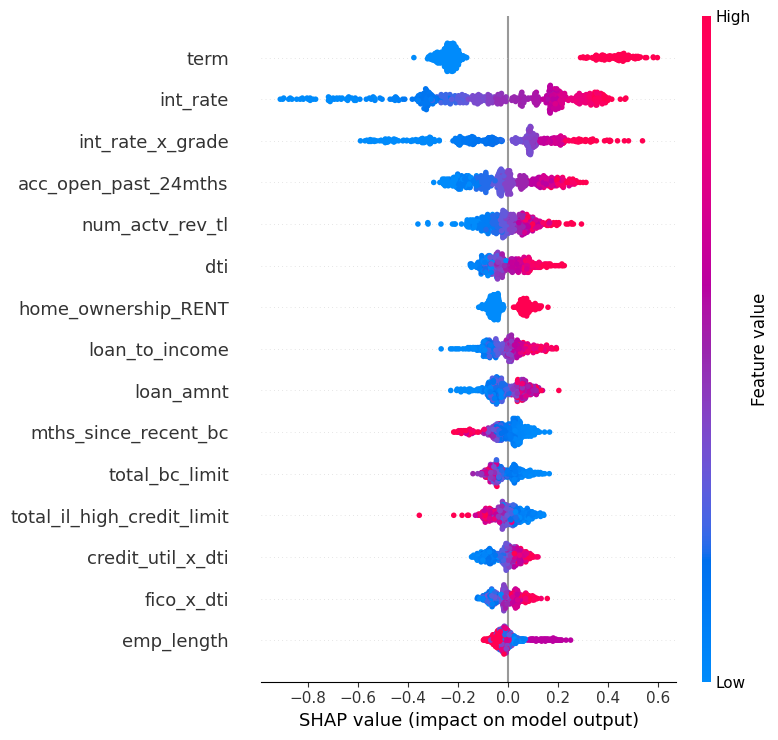

In [19]:
import shap

# Use a small sample for speed (SHAP on 390K rows will crash your Mac)
X_sample = X_test.sample(n=500, random_state=42)

# Create SHAP explainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)

# Global feature importance — which features matter most overall
shap.summary_plot(shap_values, X_sample, max_display=15, show=True)

In [20]:
# Pick a high-risk borrower from test set
idx = 0
borrower = X_sample.iloc[[idx]]
risk_score = model.predict_proba(borrower)[:, 1][0]

print(f"Borrower risk score: {risk_score:.2f}")
print(f"Actual outcome: {'DEFAULT' if y_test.iloc[X_sample.index[idx]] == 1 else 'PAID'}\n")

# Show why this borrower got this score
shap.force_plot(explainer.expected_value, shap_values[idx], X_sample.iloc[idx], matplotlib=True)

Borrower risk score: 0.22


IndexError: single positional indexer is out-of-bounds

Borrower risk score: 0.22


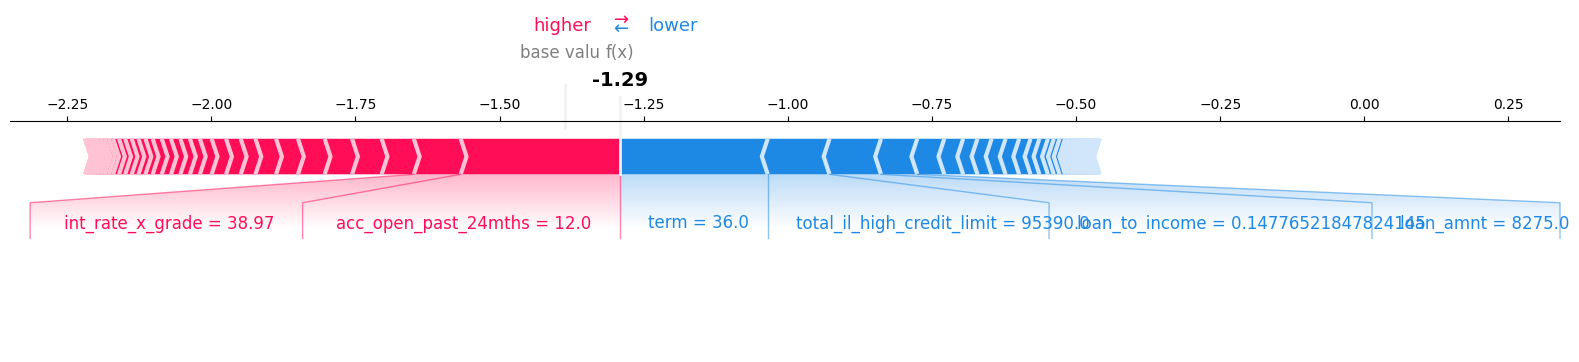

In [21]:
idx = 0
borrower = X_sample.iloc[[idx]]
risk_score = model.predict_proba(borrower)[:, 1][0]

print(f"Borrower risk score: {risk_score:.2f}")

# Show why this borrower got this score
shap.force_plot(explainer.expected_value, shap_values[idx], X_sample.iloc[idx], matplotlib=True)

Risk score: 0.74

  term: 60.00 — ↑ increases risk (SHAP: 0.450)
  int_rate_x_grade: 137.94 — ↑ increases risk (SHAP: 0.406)
  int_rate: 22.99 — ↑ increases risk (SHAP: 0.390)
  num_actv_rev_tl: 19.00 — ↑ increases risk (SHAP: 0.203)
  dti: 31.27 — ↑ increases risk (SHAP: 0.146)


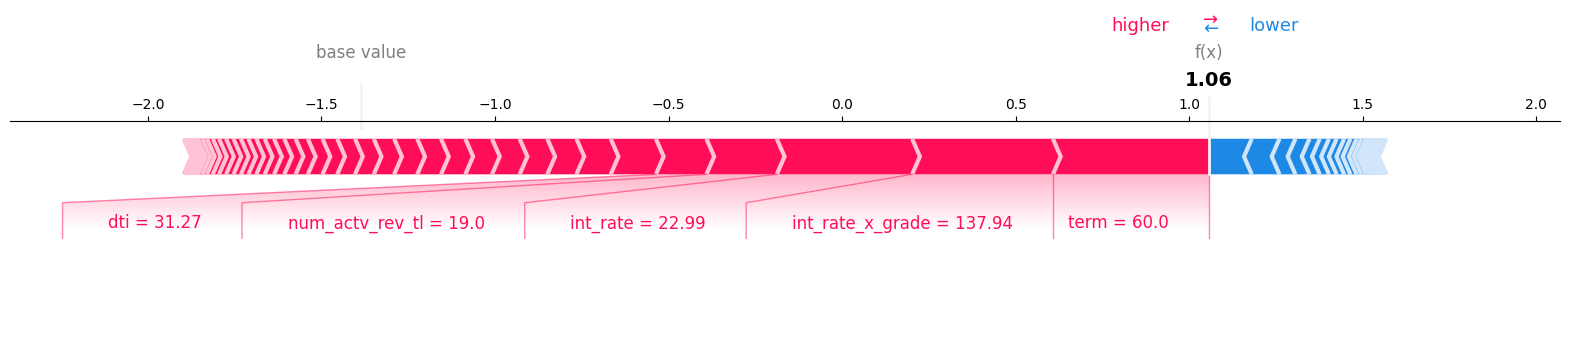

In [22]:
# Find a high-risk borrower
risk_scores = model.predict_proba(X_sample)[:, 1]
high_risk_idx = risk_scores.argmax()

print(f"Risk score: {risk_scores[high_risk_idx]:.2f}\n")

# Top 5 reasons for this borrower's risk
borrower_shap = pd.Series(shap_values[high_risk_idx], index=X_sample.columns)
top_reasons = borrower_shap.abs().sort_values(ascending=False).head(5)

for feat in top_reasons.index:
    direction = "↑ increases risk" if borrower_shap[feat] > 0 else "↓ decreases risk"
    print(f"  {feat}: {X_sample.iloc[high_risk_idx][feat]:.2f} — {direction} (SHAP: {borrower_shap[feat]:.3f})")

# Plot
shap.force_plot(explainer.expected_value, shap_values[high_risk_idx], X_sample.iloc[high_risk_idx], matplotlib=True)

In [23]:
# Save the SHAP explainer too
joblib.dump(explainer, '/Users/rishitgambhir17/loansense/models/shap_explainer.joblib')

print("=== Week 1 Progress ===")
print(f"Model: XGBoost v1")
print(f"AUC-ROC: 0.7432")
print(f"Features: {len(X.columns)}")
print(f"Training rows: {len(X_train)}")
print(f"SHAP: Working")
print(f"\nFiles saved:")
print(f"  models/xgboost_v1.joblib")
print(f"  models/shap_explainer.joblib")
print(f"  models/feature_names.txt")
print(f"  data/cleaned_full.csv")

=== Week 1 Progress ===
Model: XGBoost v1
AUC-ROC: 0.7432
Features: 77
Training rows: 312931
SHAP: Working

Files saved:
  models/xgboost_v1.joblib
  models/shap_explainer.joblib
  models/feature_names.txt
  data/cleaned_full.csv
